In [1]:
# =========================================================
# TASK 15 — CELL 1
# SETUP + LOAD TASK 14 PARAMETERS
# =========================================================

import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------------------------------------
# Project root
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RANDOM_STATE = 42

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

models_dir = PROJECT_ROOT / "models"
artifacts_dir = PROJECT_ROOT / "artifacts"

parameters_path = (
    artifacts_dir / "task14_cluster_parameters.json"
)

scaled_data_path = (
    artifacts_dir / "task14_scaled_features.csv"
)

# ---------------------------------------------------------
# Verify Task 14 artifacts
# ---------------------------------------------------------

assert parameters_path.exists(), (
    f"Missing artifact: {parameters_path}"
)

assert scaled_data_path.exists(), (
    f"Missing artifact: {scaled_data_path}"
)

# ---------------------------------------------------------
# Load parameters
# ---------------------------------------------------------

with open(parameters_path, "r") as file:
    task14_parameters = json.load(file)

selected_k = int(
    task14_parameters["selected_k"]
)

selected_features = task14_parameters[
    "selected_features"
]

# ---------------------------------------------------------
# Load prepared scaled data
# ---------------------------------------------------------

X_scaled_df = pd.read_csv(
    scaled_data_path
)

X_scaled = X_scaled_df.values

# ---------------------------------------------------------
# Display configuration
# ---------------------------------------------------------

print("=" * 60)
print("TASK 15 — K-MEANS CLUSTERING")
print("=" * 60)

print("\nTask 14 selected k:", selected_k)

print("\nSelected features:")
for feature in selected_features:
    print(" -", feature)

print("\nPrepared data shape:", X_scaled.shape)

print("\nTask 14 artifacts loaded successfully.")

TASK 15 — K-MEANS CLUSTERING

Task 14 selected k: 2

Selected features:
 - sepal length (cm)
 - sepal width (cm)
 - petal length (cm)
 - petal width (cm)

Prepared data shape: (150, 4)

Task 14 artifacts loaded successfully.


In [2]:
# =========================================================
# TASK 15 — CELL 2
# LOAD ORIGINAL IRIS DATA FOR CLUSTER PROFILING
# =========================================================

from src.data import load_data

# Load original Iris dataset
df = load_data()

print("========== ORIGINAL DATA ==========")

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nTarget distribution:")
print(df["target"].value_counts().sort_index())

# ---------------------------------------------------------
# Verify selected features
# ---------------------------------------------------------

X_original = df[selected_features].copy()

y_original = df["target"].copy()

print("\n========== CLUSTERING FEATURES ==========")

print("Selected feature shape:", X_original.shape)

print("\nSelected features:")
print(X_original.columns.tolist())

print("\nOriginal feature summary:")
print(X_original.describe().round(3))

========== ORIGINAL DATA ==========
Dataset shape: (150, 5)

Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Target distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

========== CLUSTERING FEATURES ==========
Selected feature shape: (150, 4)

Selected features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Original feature

In [3]:
# =========================================================
# TASK 15 — CELL 3
# RUN K-MEANS WITH SELECTED K
# =========================================================

# Create K-Means model using the k selected in Task 14
kmeans_model = KMeans(
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=10
)

# Fit K-Means on the prepared scaled data
cluster_labels = kmeans_model.fit_predict(X_scaled)

# Add cluster labels to a copy of the original data
clustered_df = X_original.copy()
clustered_df["cluster"] = cluster_labels

print("========== K-MEANS CLUSTERING ==========")

print("Selected k:", selected_k)
print("Random state:", RANDOM_STATE)
print("n_init:", 10)

print("\nCluster labels assigned successfully.")

print("\nCluster distribution:")
print(
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

print("\nCluster centers shape:")
print(kmeans_model.cluster_centers_.shape)

print("\nCluster centers in scaled feature space:")
print(
    pd.DataFrame(
        kmeans_model.cluster_centers_,
        columns=selected_features
    ).round(4)
)

========== K-MEANS CLUSTERING ==========
Selected k: 2
Random state: 42
n_init: 10

Cluster labels assigned successfully.

Cluster distribution:
0    100
1     50
Name: count, dtype: int64

Cluster centers shape:
(2, 4)

Cluster centers in scaled feature space:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0             0.5073           -0.4266             0.6525            0.6274
1            -1.0146            0.8533            -1.3050           -1.2549


In [4]:
# =========================================================
# TASK 15 — CELL 4
# CLUSTER QUALITY EVALUATION
# =========================================================

# Inertia from the fitted K-Means model
inertia_value = kmeans_model.inertia_

# Silhouette score
silhouette_value = silhouette_score(
    X_scaled,
    cluster_labels
)

print("========== CLUSTER QUALITY ==========")

print(f"Number of clusters (k): {selected_k}")
print(f"Inertia                : {inertia_value:.4f}")
print(f"Silhouette Score       : {silhouette_value:.4f}")

# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------

print("\n========== QUALITY INTERPRETATION ==========")

if silhouette_value >= 0.70:
    interpretation = "Strong cluster separation"
elif silhouette_value >= 0.50:
    interpretation = "Good cluster separation"
elif silhouette_value >= 0.25:
    interpretation = "Moderate cluster separation"
else:
    interpretation = "Weak cluster separation"

print("Silhouette interpretation:", interpretation)

print("\nInertia represents the within-cluster sum of squared")
print("distances between observations and their cluster centers.")

========== CLUSTER QUALITY ==========
Number of clusters (k): 2
Inertia                : 222.3617
Silhouette Score       : 0.5818

========== QUALITY INTERPRETATION ==========
Silhouette interpretation: Good cluster separation

Inertia represents the within-cluster sum of squared
distances between observations and their cluster centers.


In [5]:
# =========================================================
# TASK 15 — CELL 5
# CLUSTER PROFILING
# =========================================================

# Calculate mean feature values for each cluster
cluster_profile = (
    clustered_df
    .groupby("cluster")[selected_features]
    .mean()
    .round(3)
)

print("========== CLUSTER PROFILE ==========")

print(cluster_profile)

# ---------------------------------------------------------
# Cluster sizes
# ---------------------------------------------------------

cluster_sizes = (
    clustered_df["cluster"]
    .value_counts()
    .sort_index()
)

print("\n========== CLUSTER SIZES ==========")

for cluster_id, size in cluster_sizes.items():
    percentage = (size / len(clustered_df)) * 100

    print(
        f"Cluster {cluster_id}: "
        f"{size} samples "
        f"({percentage:.1f}%)"
    )

# ---------------------------------------------------------
# Feature ranges by cluster
# ---------------------------------------------------------

print("\n========== CLUSTER FEATURE RANGES ==========")

for cluster_id in sorted(clustered_df["cluster"].unique()):

    cluster_data = clustered_df[
        clustered_df["cluster"] == cluster_id
    ]

    print(f"\nCluster {cluster_id}:")

    for feature in selected_features:

        minimum = cluster_data[feature].min()
        maximum = cluster_data[feature].max()

        print(
            f"  {feature}: "
            f"{minimum:.2f} → {maximum:.2f}"
        )

========== CLUSTER PROFILE ==========
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
cluster                                                           
0                    6.262             2.872              4.906   
1                    5.006             3.428              1.462   

         petal width (cm)  
cluster                    
0                   1.676  
1                   0.246  

========== CLUSTER SIZES ==========
Cluster 0: 100 samples (66.7%)
Cluster 1: 50 samples (33.3%)

========== CLUSTER FEATURE RANGES ==========

Cluster 0:
  sepal length (cm): 4.90 → 7.90
  sepal width (cm): 2.00 → 3.80
  petal length (cm): 3.00 → 6.90
  petal width (cm): 1.00 → 2.50

Cluster 1:
  sepal length (cm): 4.30 → 5.80
  sepal width (cm): 2.30 → 4.40
  petal length (cm): 1.00 → 1.90
  petal width (cm): 0.10 → 0.60


In [6]:
# =========================================================
# TASK 15 — CELL 6
# NAME CLUSTERS + RECOMMENDED ACTIONS
# =========================================================

# ---------------------------------------------------------
# Define meaningful cluster names
# ---------------------------------------------------------

cluster_names = {
    0: "Larger-Petal Flower Group",
    1: "Small-Petal Flower Group"
}

# Recommended actions for each segment
cluster_actions = {
    0: (
        "Prioritize detailed measurement-based classification "
        "because this group contains larger petal dimensions."
    ),
    1: (
        "Use the compact petal profile as a strong distinguishing "
        "characteristic for this group."
    )
}

# Add names to clustered dataset
clustered_df["cluster_name"] = (
    clustered_df["cluster"]
    .map(cluster_names)
)

# Add recommended actions
clustered_df["recommended_action"] = (
    clustered_df["cluster"]
    .map(cluster_actions)
)

# ---------------------------------------------------------
# Display segment summary
# ---------------------------------------------------------

segment_summary = (
    clustered_df
    .groupby(
        ["cluster", "cluster_name"],
        as_index=False
    )
    .agg(
        samples=("cluster", "size"),
        avg_sepal_length=("sepal length (cm)", "mean"),
        avg_sepal_width=("sepal width (cm)", "mean"),
        avg_petal_length=("petal length (cm)", "mean"),
        avg_petal_width=("petal width (cm)", "mean")
    )
)

# Round numerical values
numeric_columns = [
    "avg_sepal_length",
    "avg_sepal_width",
    "avg_petal_length",
    "avg_petal_width"
]

segment_summary[numeric_columns] = (
    segment_summary[numeric_columns]
    .round(3)
)

print("========== NAMED CLUSTERS ==========")

print(
    segment_summary.to_string(index=False)
)

print("\n========== RECOMMENDED ACTIONS ==========")

for cluster_id in sorted(cluster_names):

    print(f"\nCluster {cluster_id}")
    print(f"Name   : {cluster_names[cluster_id]}")
    print(f"Action : {cluster_actions[cluster_id]}")

========== NAMED CLUSTERS ==========
 cluster              cluster_name  samples  avg_sepal_length  avg_sepal_width  avg_petal_length  avg_petal_width
       0 Larger-Petal Flower Group      100             6.262            2.872             4.906            1.676
       1  Small-Petal Flower Group       50             5.006            3.428             1.462            0.246

========== RECOMMENDED ACTIONS ==========

Cluster 0
Name   : Larger-Petal Flower Group
Action : Prioritize detailed measurement-based classification because this group contains larger petal dimensions.

Cluster 1
Name   : Small-Petal Flower Group
Action : Use the compact petal profile as a strong distinguishing characteristic for this group.


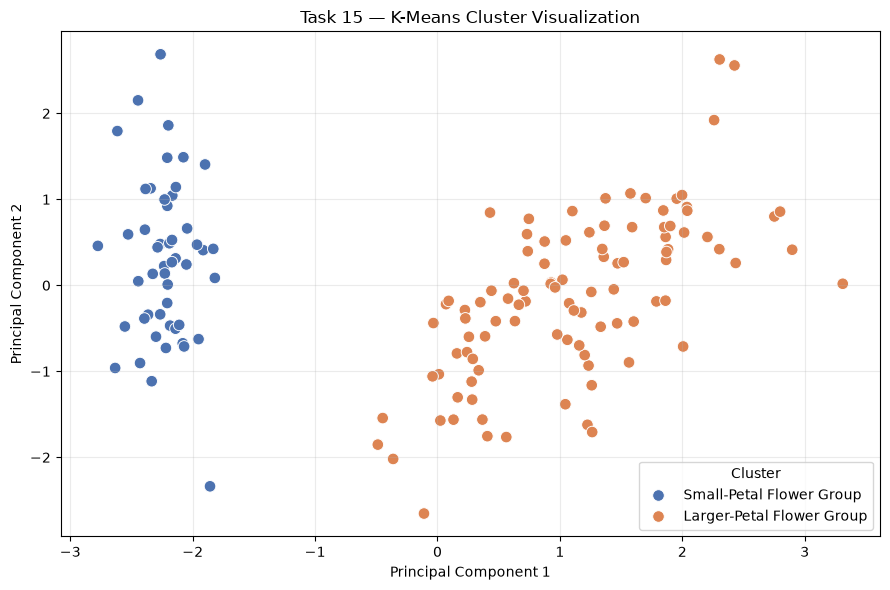

========== PCA VISUALIZATION ==========
PC1 explained variance: 0.7296
PC2 explained variance: 0.2285
Total explained variance: 0.9581


In [7]:
# =========================================================
# TASK 15 — CELL 7
# CLUSTER VISUALIZATION
# =========================================================

from sklearn.decomposition import PCA

# Reduce the already-scaled features to 2 dimensions
# for visualization only.
pca_visualization = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca_visualization = pca_visualization.fit_transform(
    X_scaled
)

visualization_df = pd.DataFrame({
    "PC1": X_pca_visualization[:, 0],
    "PC2": X_pca_visualization[:, 1],
    "cluster": cluster_labels
})

# Add readable cluster names
visualization_df["cluster_name"] = (
    visualization_df["cluster"]
    .map(cluster_names)
)

# ---------------------------------------------------------
# Plot clusters
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=visualization_df,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    palette="deep",
    s=70
)

plt.title("Task 15 — K-Means Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Explained variance
# ---------------------------------------------------------

explained_variance = (
    pca_visualization
    .explained_variance_ratio_
)

print("========== PCA VISUALIZATION ==========")

print(
    f"PC1 explained variance: "
    f"{explained_variance[0]:.4f}"
)

print(
    f"PC2 explained variance: "
    f"{explained_variance[1]:.4f}"
)

print(
    f"Total explained variance: "
    f"{explained_variance.sum():.4f}"
)

In [8]:
# =========================================================
# TASK 15 — CELL 8
# K-MEANS STABILITY ACROSS RANDOM SEEDS
# =========================================================

from sklearn.metrics import adjusted_rand_score

# Seeds to test
stability_seeds = [0, 7, 21, 42, 99]

stability_results = []

# Reference clustering from Task 15
reference_labels = cluster_labels

for seed in stability_seeds:

    stability_model = KMeans(
        n_clusters=selected_k,
        random_state=seed,
        n_init=10
    )

    seed_labels = stability_model.fit_predict(
        X_scaled
    )

    # Compare this clustering with the reference
    ari_score = adjusted_rand_score(
        reference_labels,
        seed_labels
    )

    seed_silhouette = silhouette_score(
        X_scaled,
        seed_labels
    )

    stability_results.append({
        "Seed": seed,
        "Adjusted_Rand_Index": ari_score,
        "Silhouette_Score": seed_silhouette,
        "Inertia": stability_model.inertia_
    })

stability_df = pd.DataFrame(
    stability_results
)

print("========== K-MEANS STABILITY ==========")

print(
    stability_df.round(4).to_string(index=False)
)

print("\n========== STABILITY SUMMARY ==========")

print(
    f"Mean ARI        : "
    f"{stability_df['Adjusted_Rand_Index'].mean():.4f}"
)

print(
    f"Minimum ARI     : "
    f"{stability_df['Adjusted_Rand_Index'].min():.4f}"
)

print(
    f"Mean Silhouette : "
    f"{stability_df['Silhouette_Score'].mean():.4f}"
)

print(
    f"Silhouette Std  : "
    f"{stability_df['Silhouette_Score'].std():.4f}"
)

# ---------------------------------------------------------
# Stability interpretation
# ---------------------------------------------------------

mean_ari = stability_df[
    "Adjusted_Rand_Index"
].mean()

if mean_ari >= 0.90:
    stability_interpretation = "Highly stable clustering"
elif mean_ari >= 0.75:
    stability_interpretation = "Stable clustering"
elif mean_ari >= 0.50:
    stability_interpretation = "Moderately stable clustering"
else:
    stability_interpretation = "Potentially unstable clustering"

print(
    "\nStability interpretation:",
    stability_interpretation
)

========== K-MEANS STABILITY ==========
 Seed  Adjusted_Rand_Index  Silhouette_Score  Inertia
    0                  1.0            0.5818 222.3617
    7                  1.0            0.5818 222.3617
   21                  1.0            0.5818 222.3617
   42                  1.0            0.5818 222.3617
   99                  1.0            0.5818 222.3617

========== STABILITY SUMMARY ==========
Mean ARI        : 1.0000
Minimum ARI     : 1.0000
Mean Silhouette : 0.5818
Silhouette Std  : 0.0000

Stability interpretation: Highly stable clustering


In [9]:
# =========================================================
# TASK 15 — CELL 9
# SAVE K-MEANS MODEL + RESULTS
# =========================================================

# Create directories if they don't exist
models_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Save K-Means model
# ---------------------------------------------------------

kmeans_model_path = (
    models_dir / "task15_kmeans_model.pkl"
)

joblib.dump(
    kmeans_model,
    kmeans_model_path
)

# ---------------------------------------------------------
# Save cluster profile
# ---------------------------------------------------------

cluster_profile_path = (
    artifacts_dir / "task15_cluster_profile.csv"
)

cluster_profile.to_csv(
    cluster_profile_path
)

# ---------------------------------------------------------
# Save stability results
# ---------------------------------------------------------

stability_path = (
    artifacts_dir / "task15_cluster_stability.csv"
)

stability_df.to_csv(
    stability_path,
    index=False
)

# ---------------------------------------------------------
# Save complete clustered dataset
# ---------------------------------------------------------

clustered_data_path = (
    artifacts_dir / "task15_clustered_data.csv"
)

clustered_df.to_csv(
    clustered_data_path,
    index=False
)

# ---------------------------------------------------------
# Save final metrics
# ---------------------------------------------------------

final_metrics = pd.DataFrame([{
    "k": selected_k,
    "inertia": inertia_value,
    "silhouette_score": silhouette_value,
    "mean_ari": stability_df[
        "Adjusted_Rand_Index"
    ].mean(),
    "minimum_ari": stability_df[
        "Adjusted_Rand_Index"
    ].min(),
    "mean_stability_silhouette": stability_df[
        "Silhouette_Score"
    ].mean()
}])

metrics_path = (
    artifacts_dir / "task15_clustering_metrics.csv"
)

final_metrics.to_csv(
    metrics_path,
    index=False
)

print("========== TASK 15 ARTIFACTS ==========")

print("K-Means model:")
print(kmeans_model_path)

print("\nCluster profile:")
print(cluster_profile_path)

print("\nStability results:")
print(stability_path)

print("\nClustered dataset:")
print(clustered_data_path)

print("\nClustering metrics:")
print(metrics_path)

print("\nAll Task 15 artifacts saved successfully.")

========== TASK 15 ARTIFACTS ==========
K-Means model:
/home/akash/Projects/Altrodav/models/task15_kmeans_model.pkl

Cluster profile:
/home/akash/Projects/Altrodav/artifacts/task15_cluster_profile.csv

Stability results:
/home/akash/Projects/Altrodav/artifacts/task15_cluster_stability.csv

Clustered dataset:
/home/akash/Projects/Altrodav/artifacts/task15_clustered_data.csv

Clustering metrics:
/home/akash/Projects/Altrodav/artifacts/task15_clustering_metrics.csv

All Task 15 artifacts saved successfully.


In [10]:
# =========================================================
# TASK 15 — CELL 10
# FINAL VERIFICATION
# =========================================================

import joblib
import pandas as pd
import numpy as np

print("=" * 65)
print("        TASK 15 — FINAL VERIFICATION")
print("=" * 65)

# ---------------------------------------------------------
# Verify K-Means model can be loaded
# ---------------------------------------------------------

loaded_kmeans = joblib.load(
    kmeans_model_path
)

print("\nK-Means model loading : PASS")

# ---------------------------------------------------------
# Verify saved clustered dataset
# ---------------------------------------------------------

loaded_clustered_data = pd.read_csv(
    clustered_data_path
)

print("Clustered dataset loading : PASS")

# ---------------------------------------------------------
# Verify saved metrics
# ---------------------------------------------------------

loaded_metrics = pd.read_csv(
    metrics_path
)

print("Metrics loading : PASS")

# ---------------------------------------------------------
# Verify saved stability results
# ---------------------------------------------------------

loaded_stability = pd.read_csv(
    stability_path
)

print("Stability results loading : PASS")

# ---------------------------------------------------------
# Verify model configuration
# ---------------------------------------------------------

print("\n========== MODEL CONFIGURATION ==========")

print(
    "Number of clusters :",
    loaded_kmeans.n_clusters
)

print(
    "Random state       :",
    loaded_kmeans.random_state
)

print(
    "Number of features :",
    loaded_kmeans.cluster_centers_.shape[1]
)

# ---------------------------------------------------------
# Verify cluster labels
# ---------------------------------------------------------

loaded_labels = loaded_kmeans.predict(
    X_scaled
)

labels_match = np.array_equal(
    loaded_labels,
    cluster_labels
)

print(
    "\nSaved model predictions match "
    f"original clustering : "
    f"{'PASS' if labels_match else 'FAIL'}"
)

# ---------------------------------------------------------
# Verify metrics
# ---------------------------------------------------------

print("\n========== CLUSTER QUALITY ==========")

print(
    f"Inertia          : "
    f"{loaded_metrics['inertia'].iloc[0]:.4f}"
)

print(
    f"Silhouette Score : "
    f"{loaded_metrics['silhouette_score'].iloc[0]:.4f}"
)

print(
    f"Mean ARI         : "
    f"{loaded_metrics['mean_ari'].iloc[0]:.4f}"
)

# ---------------------------------------------------------
# Verify cluster distribution
# ---------------------------------------------------------

print("\n========== CLUSTER DISTRIBUTION ==========")

print(
    loaded_clustered_data["cluster"]
    .value_counts()
    .sort_index()
)

# ---------------------------------------------------------
# Final status
# ---------------------------------------------------------

all_checks_passed = (
    loaded_kmeans.n_clusters == selected_k
    and labels_match
    and len(loaded_clustered_data) == len(X_scaled)
    and loaded_metrics["silhouette_score"].iloc[0] > 0
    and loaded_metrics["mean_ari"].iloc[0] >= 0.90
)

print("\n" + "=" * 65)

if all_checks_passed:
    print("TASK 15 COMPLETED SUCCESSFULLY!")
else:
    print("TASK 15 VERIFICATION FAILED — REVIEW RESULTS")

print("=" * 65)

        TASK 15 — FINAL VERIFICATION

K-Means model loading : PASS
Clustered dataset loading : PASS
Metrics loading : PASS
Stability results loading : PASS

========== MODEL CONFIGURATION ==========
Number of clusters : 2
Random state       : 42
Number of features : 4

Saved model predictions match original clustering : PASS

========== CLUSTER QUALITY ==========
Inertia          : 222.3617
Silhouette Score : 0.5818
Mean ARI         : 1.0000

========== CLUSTER DISTRIBUTION ==========
cluster
0    100
1     50
Name: count, dtype: int64

TASK 15 COMPLETED SUCCESSFULLY!
